# Customer Churn Analysis - Telecom (Telco Customer Churn)
**Goal:** understand why customers leave, quantify the revenue at risk, and build a model that flags likely churners.

**Dataset:** Telco Customer Churn (7,043 customers, 21 columns).

**Steps:** 1) Data cleaning 2) EDA 3) Churn drivers 4) Modelling 5) Business recommendations

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
sns.set_style('whitegrid')

## 1. Load and inspect data

In [2]:
df = pd.read_csv('../data/Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 2. Data cleaning
`TotalCharges` is stored as text because 11 rows (new customers with tenure 0) are blank. We convert to numeric and fill with 0, since these customers have not been billed yet.

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
print('Blank TotalCharges:', df['TotalCharges'].isna().sum())
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print('Duplicate customer IDs:', df.customerID.duplicated().sum())
df['ChurnFlag'] = (df.Churn == 'Yes').astype(int)

Blank TotalCharges: 11
Duplicate customer IDs: 0


## 3. Exploratory data analysis

In [5]:
rate = df.ChurnFlag.mean()*100
print(f'Overall churn rate: {rate:.2f}%  ({df.ChurnFlag.sum()} of {len(df)} customers)')
print('Avg monthly charge - churned:', round(df[df.ChurnFlag==1].MonthlyCharges.mean(),2), '| stayed:', round(df[df.ChurnFlag==0].MonthlyCharges.mean(),2))
print('Median tenure - churned:', df[df.ChurnFlag==1].tenure.median(), '| stayed:', df[df.ChurnFlag==0].tenure.median())
print('Monthly revenue from churned customers:', round(df[df.ChurnFlag==1].MonthlyCharges.sum()), 'of', round(df.MonthlyCharges.sum()))

Overall churn rate: 26.54%  (1869 of 7043 customers)
Avg monthly charge - churned: 74.44 | stayed: 61.27
Median tenure - churned: 10.0 | stayed: 38.0
Monthly revenue from churned customers: 139131 of 456117


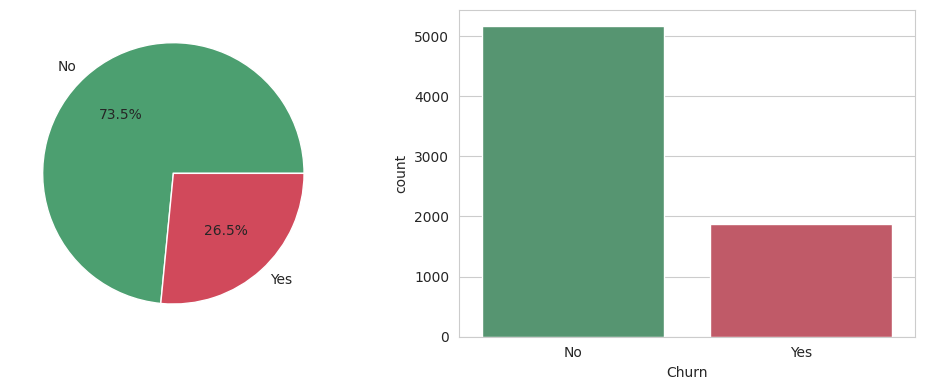

In [6]:
fig,ax=plt.subplots(1,2,figsize=(10,4))
df.Churn.value_counts().plot.pie(autopct='%1.1f%%',ax=ax[0],colors=['#4C9F70','#D1495B'],ylabel='')
sns.countplot(x='Churn',data=df,ax=ax[1],palette=['#4C9F70','#D1495B'])
plt.tight_layout();plt.show()

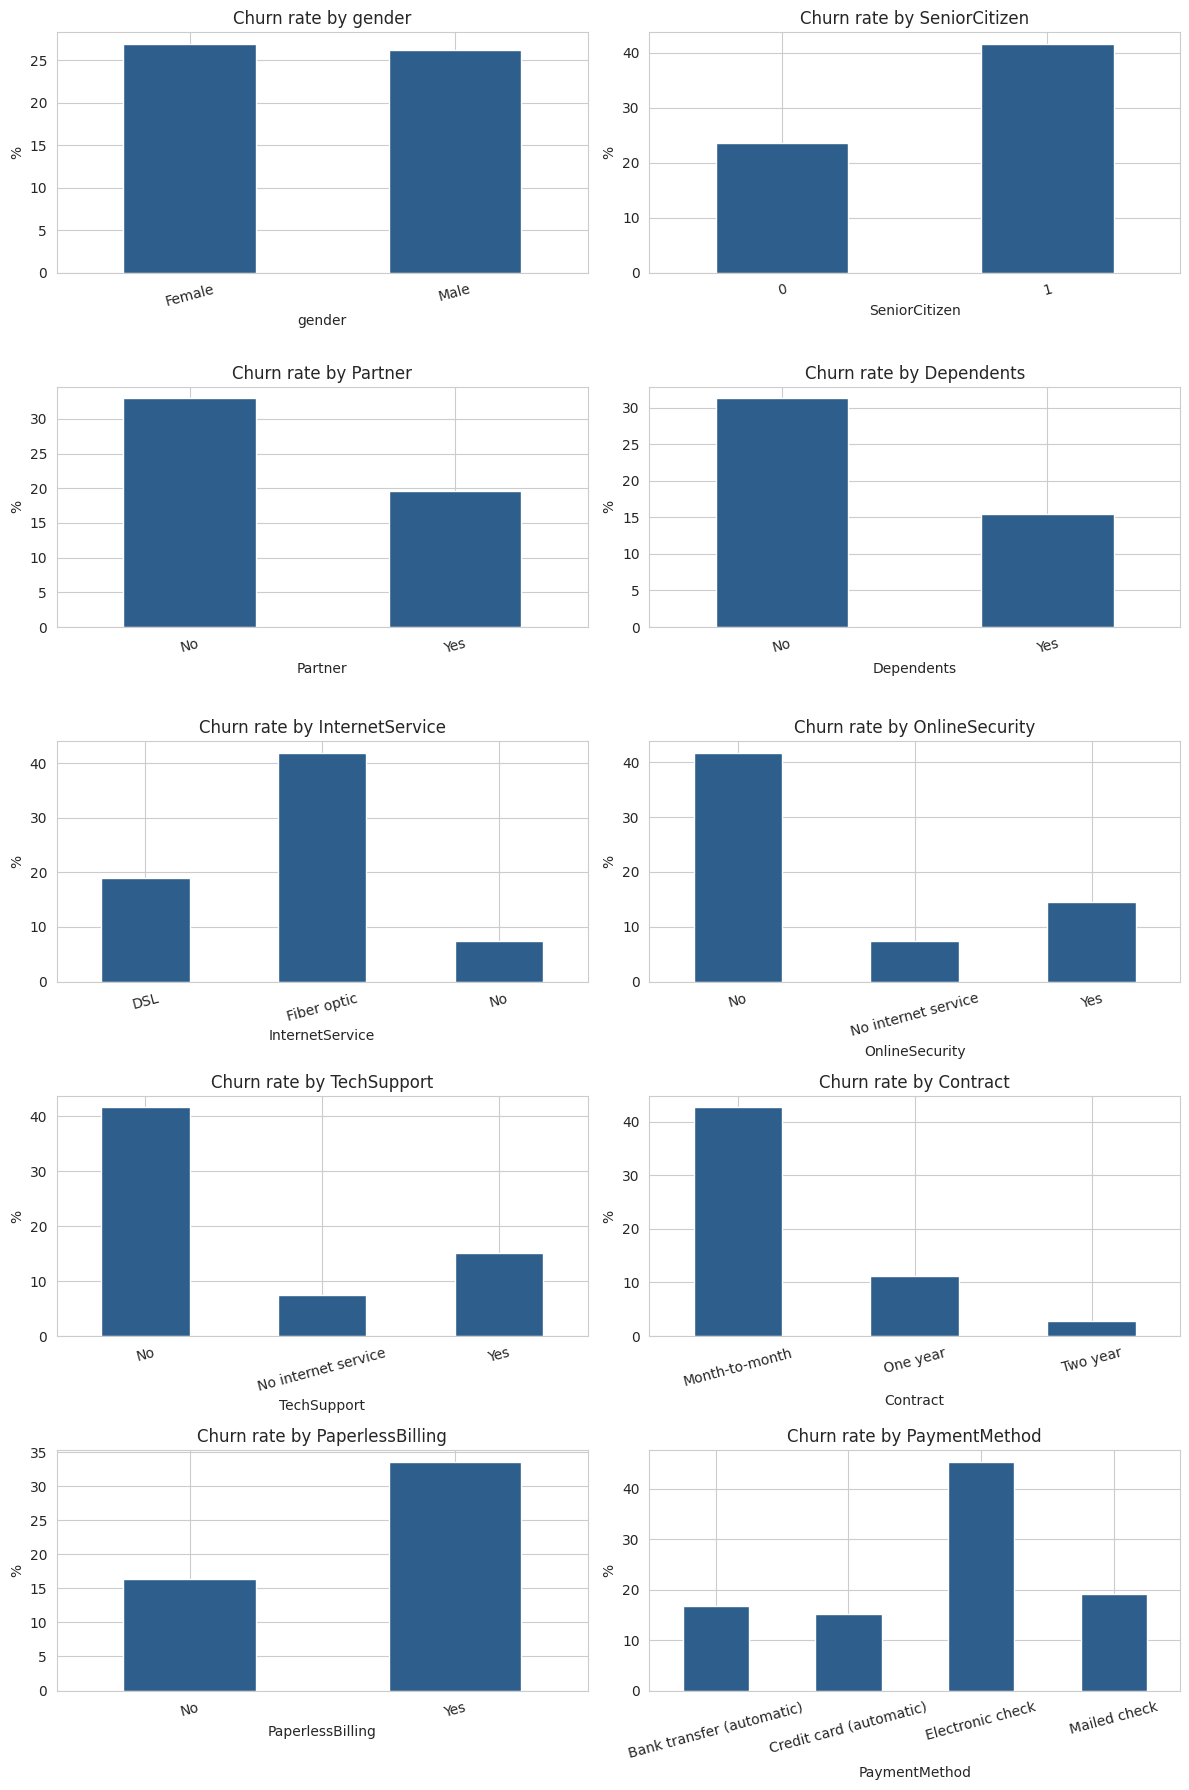

In [7]:
cats=['gender','SeniorCitizen','Partner','Dependents','InternetService','OnlineSecurity','TechSupport','Contract','PaperlessBilling','PaymentMethod']
fig,axes=plt.subplots(5,2,figsize=(12,18))
for a,c in zip(axes.ravel(),cats):
    d=df.groupby(c).ChurnFlag.mean().mul(100)
    d.plot.bar(ax=a,color='#2E5E8C');a.set_title(f'Churn rate by {c}');a.set_ylabel('%');a.tick_params(axis='x',rotation=15)
plt.tight_layout();plt.show()

In [8]:
df['TenureBand']=pd.cut(df.tenure,[-1,12,24,48,72],labels=['0-12','13-24','25-48','49-72'])
df['ChargeBand']=pd.cut(df.MonthlyCharges,[0,35,70,90,200],labels=['<35','35-70','70-90','90+'])
print(df.groupby('TenureBand',observed=True).ChurnFlag.mean().mul(100).round(1))
print(df.groupby('ChargeBand',observed=True).ChurnFlag.mean().mul(100).round(1))

TenureBand
0-12     47.4
13-24    28.7
25-48    20.4
49-72     9.5
Name: ChurnFlag, dtype: float64
ChargeBand
<35      10.9
35-70    23.9
70-90    37.8
90+      32.8
Name: ChurnFlag, dtype: float64


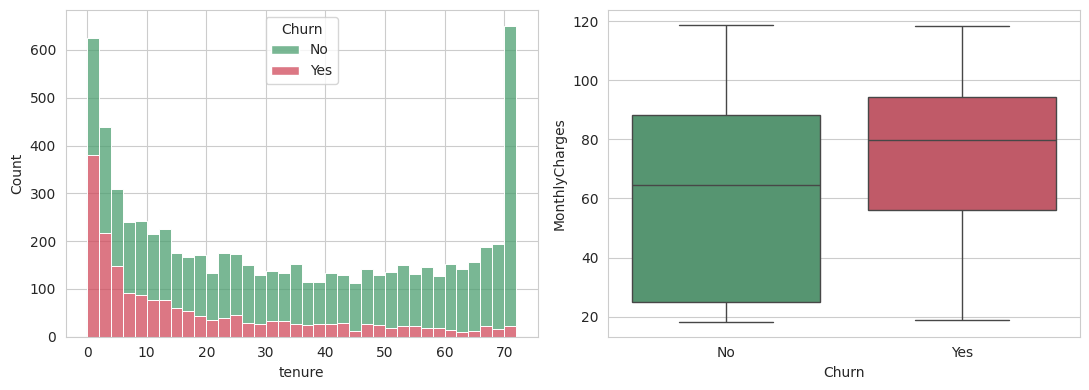

                tenure  MonthlyCharges  TotalCharges  ChurnFlag
tenure            1.00            0.25          0.83      -0.35
MonthlyCharges    0.25            1.00          0.65       0.19
TotalCharges      0.83            0.65          1.00      -0.20
ChurnFlag        -0.35            0.19         -0.20       1.00


In [9]:
fig,ax=plt.subplots(1,2,figsize=(11,4))
sns.histplot(data=df,x='tenure',hue='Churn',bins=36,multiple='stack',ax=ax[0],palette=['#4C9F70','#D1495B'])
sns.boxplot(data=df,x='Churn',y='MonthlyCharges',ax=ax[1],palette=['#4C9F70','#D1495B'])
plt.tight_layout();plt.show()
print(df[['tenure','MonthlyCharges','TotalCharges','ChurnFlag']].corr().round(2))

**EDA findings**
- 26.5% of customers churned.
- Month-to-month contracts churn at 42.7% vs 2.8% for two-year contracts.
- Fibre optic customers churn at 41.9%; customers without internet churn at 7.4%.
- Electronic-check payers churn at 45.3%, versus about 15-19% for other payment methods.
- Customers without Online Security or Tech Support churn at about 42%, versus about 15% for those with them.
- Churn is highest in the first 12 months of tenure (47.4%).
- Gender has almost no effect.

## 4. Modelling

In [10]:
X=df.drop(columns=['customerID','Churn','ChurnFlag','TenureBand','ChargeBand'])
X=pd.get_dummies(X,drop_first=True);y=df.ChurnFlag
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
num=['tenure','MonthlyCharges','TotalCharges']
sc=StandardScaler().fit(Xtr[num])
Xtr_s,Xte_s=Xtr.copy(),Xte.copy()
Xtr_s[num]=sc.transform(Xtr[num]);Xte_s[num]=sc.transform(Xte[num])
print(Xtr.shape,Xte.shape)

(5634, 30) (1409, 30)


In [11]:
models={'Logistic Regression':(LogisticRegression(max_iter=2000,class_weight='balanced'),True),
'Decision Tree':(DecisionTreeClassifier(max_depth=5,class_weight='balanced',random_state=42),False),
'Random Forest':(RandomForestClassifier(n_estimators=300,max_depth=8,class_weight='balanced',random_state=42,n_jobs=-1),False),
'Gradient Boosting':(GradientBoostingClassifier(random_state=42),False)}
cv=StratifiedKFold(5,shuffle=True,random_state=42);rows=[];probs={}
for n,(m,s) in models.items():
    a,b=(Xtr_s,Xte_s) if s else (Xtr,Xte)
    m.fit(a,ytr);p=m.predict_proba(b)[:,1];pr=(p>=0.5).astype(int);probs[n]=p
    rows.append([n,accuracy_score(yte,pr),precision_score(yte,pr),recall_score(yte,pr),f1_score(yte,pr),roc_auc_score(yte,p),cross_val_score(m,a,ytr,cv=cv,scoring='roc_auc').mean()])
res=pd.DataFrame(rows,columns=['Model','Accuracy','Precision','Recall','F1','ROC-AUC','CV ROC-AUC']).round(3)
res

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,CV ROC-AUC
0,Logistic Regression,0.738,0.504,0.783,0.614,0.842,0.846
1,Decision Tree,0.735,0.500,0.807,0.618,0.831,0.824
2,Random Forest,0.760,0.533,0.783,0.634,0.844,0.847
3,Gradient Boosting,0.798,0.655,0.508,0.572,0.842,0.847


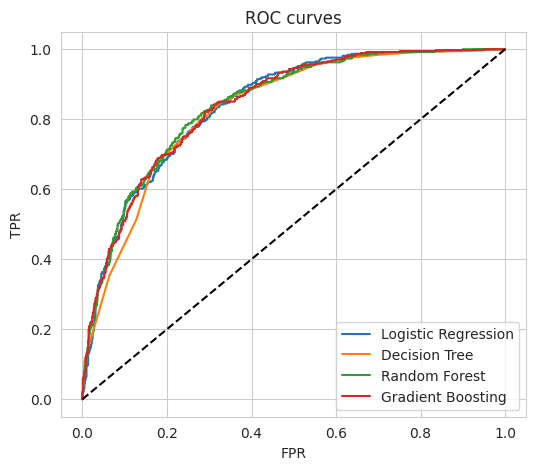

In [12]:
plt.figure(figsize=(6,5))
for n,p in probs.items():
    f,t,_=roc_curve(yte,p);plt.plot(f,t,label=n)
plt.plot([0,1],[0,1],'k--');plt.legend();plt.xlabel('FPR');plt.ylabel('TPR');plt.title('ROC curves');plt.show()

## 5. Best model - Random Forest evaluation

              precision    recall  f1-score   support

        Stay       0.91      0.75      0.82      1035
       Churn       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



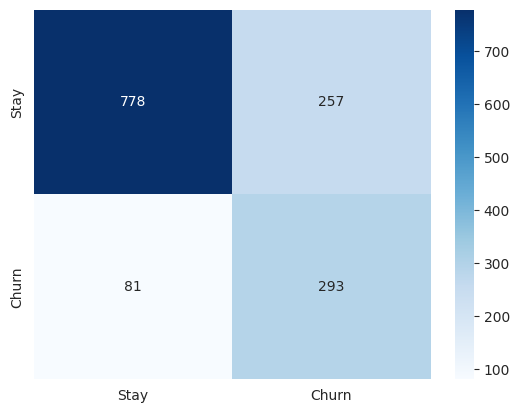

In [13]:
rf=models['Random Forest'][0];pl=probs['Random Forest'];pb=(pl>=0.5).astype(int)
print(classification_report(yte,pb,target_names=['Stay','Churn']))
sns.heatmap(confusion_matrix(yte,pb),annot=True,fmt='d',cmap='Blues',xticklabels=['Stay','Churn'],yticklabels=['Stay','Churn']);plt.show()

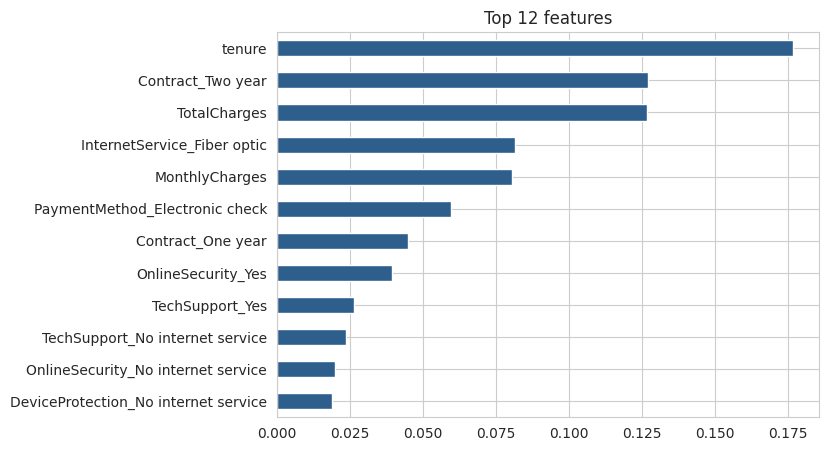

In [14]:
imp=pd.Series(rf.feature_importances_,index=X.columns).sort_values(ascending=False).head(12)
imp[::-1].plot.barh(color='#2E5E8C',figsize=(7,5));plt.title('Top 12 features');plt.show()

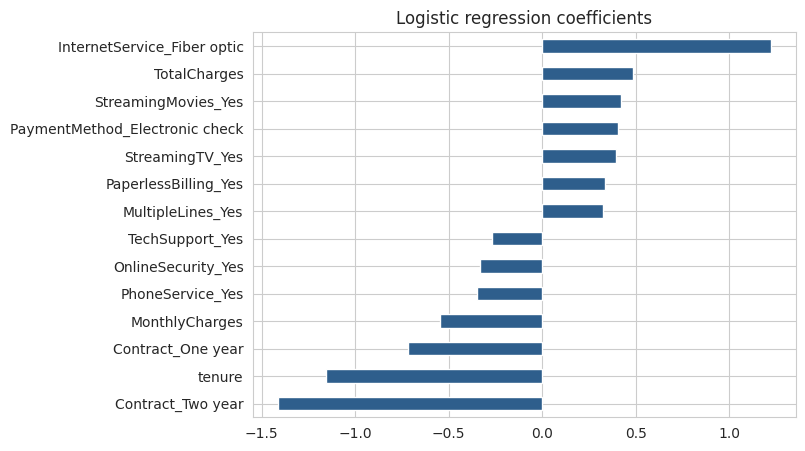

In [15]:
lr=models['Logistic Regression'][0]
co=pd.Series(lr.coef_[0],index=X.columns).sort_values()
pd.concat([co.head(7),co.tail(7)]).plot.barh(figsize=(7,5),color='#2E5E8C');plt.title('Logistic regression coefficients');plt.show()

## 6. Threshold tuning and targeting
A retention team cares more about catching churners (recall) than about a few wasted offers, so the threshold can be lowered below 0.5.

In [16]:
rows=[]
for t in np.arange(0.2,0.81,0.05):
    q=(pl>=t).astype(int);rows.append([round(t,2),precision_score(yte,q),recall_score(yte,q),f1_score(yte,q)])
pd.DataFrame(rows,columns=['Threshold','Precision','Recall','F1']).round(3)

,Threshold,Precision,Recall,F1
0,0.20,0.387,0.955,0.551
1,0.25,0.409,0.922,0.567
2,0.30,0.435,0.896,0.585
3,0.35,0.456,0.882,0.601
4,0.40,0.480,0.850,0.614
5,0.45,0.508,0.821,0.628
6,0.50,0.533,0.783,0.634
7,0.55,0.555,0.717,0.625
8,0.60,0.580,0.658,0.617
9,0.65,0.631,0.594,0.612


In [17]:
te=pd.DataFrame({'p':pl,'y':yte.values}).sort_values('p',ascending=False)
k=int(len(te)*0.2)
print(f'Targeting the top 20% highest-risk customers captures {te.y.head(k).sum()/te.y.sum()*100:.1f}% of all churners')

Targeting the top 20% highest-risk customers captures 50.8% of all churners


## 7. Business recommendations
1. Move month-to-month customers to annual contracts with a discount or free add-on.
2. Run an onboarding and early-life programme for customers in their first 12 months.
3. Bundle Online Security and Tech Support with fibre plans; review fibre pricing and service quality.
4. Push electronic-check customers toward auto-pay with a small incentive.
5. Use the model to rank customers by risk each month and give the retention team the top 20%.